In [53]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

sns.set(rc={"figure.figsize": (15, 6)})

pd.set_option("display.max_columns", None)

In [54]:
df=pd.read_csv("adult.csv")

In [55]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   age             32561 non-null  int64
 1   workclass       32561 non-null  str  
 2   fnlwgt          32561 non-null  int64
 3   education       32561 non-null  str  
 4   education.num   32561 non-null  int64
 5   marital.status  32561 non-null  str  
 6   occupation      32561 non-null  str  
 7   relationship    32561 non-null  str  
 8   race            32561 non-null  str  
 9   sex             32561 non-null  str  
 10  capital.gain    32561 non-null  int64
 11  capital.loss    32561 non-null  int64
 12  hours.per.week  32561 non-null  int64
 13  native.country  32561 non-null  str  
 14  income          32561 non-null  str  
dtypes: int64(6), str(9)
memory usage: 3.7 MB


In [56]:
df.isnull().sum()

age               0
workclass         0
fnlwgt            0
education         0
education.num     0
marital.status    0
occupation        0
relationship      0
race              0
sex               0
capital.gain      0
capital.loss      0
hours.per.week    0
native.country    0
income            0
dtype: int64

In [57]:
df.duplicated().sum()

np.int64(24)

In [58]:
df.drop_duplicates(inplace=True)

In [59]:
df.describe()

,age,fnlwgt,education.num,capital.gain,capital.loss,hours.per.week
count,32537.000000,3.253700e+04,32537.000000,32537.000000,32537.000000,32537.000000
mean,38.585549,1.897808e+05,10.081815,1078.443741,87.368227,40.440329
std,13.637984,1.055565e+05,2.571633,7387.957424,403.101833,12.346889
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178270e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783560e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.369930e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000


In [60]:
# seperate categorical and numerical feature

categorical_features=df.select_dtypes(include="object").columns
numerical_features=df.select_dtypes(exclude="object").columns

In [61]:
categorical_features

Index(['workclass', 'education', 'marital.status', 'occupation',
       'relationship', 'race', 'sex', 'native.country', 'income'],
      dtype='str')

In [62]:
numerical_features

Index(['age', 'fnlwgt', 'education.num', 'capital.gain', 'capital.loss',
       'hours.per.week'],
      dtype='str')

In [63]:
# Fetch the unique value from categorical data

for i in categorical_features:
    print(i,df[i].unique())

    print()
    print("**************************seperate_columns************")
    print()

workclass <StringArray>
[               '?',          'Private',        'State-gov',
      'Federal-gov', 'Self-emp-not-inc',     'Self-emp-inc',
        'Local-gov',      'Without-pay',     'Never-worked']
Length: 9, dtype: str

**************************seperate_columns************

education <StringArray>
[     'HS-grad', 'Some-college',      '7th-8th',         '10th',
    'Doctorate',  'Prof-school',    'Bachelors',      'Masters',
         '11th',   'Assoc-acdm',    'Assoc-voc',      '1st-4th',
      '5th-6th',         '12th',          '9th',    'Preschool']
Length: 16, dtype: str

**************************seperate_columns************

marital.status <StringArray>
[              'Widowed',              'Divorced',             'Separated',
         'Never-married',    'Married-civ-spouse', 'Married-spouse-absent',
     'Married-AF-spouse']
Length: 7, dtype: str

**************************seperate_columns************

occupation <StringArray>
[                '?',   'Exec-manageria

In [64]:
# remove ? and replace with mode value

df["workclass"]=df["workclass"].replace("?","Private")
df["occupation"]=df["occupation"].replace("?","Prof-specialty")
df["native.country"]=df["native.country"].replace("?","United-states")

## data Vizualization 

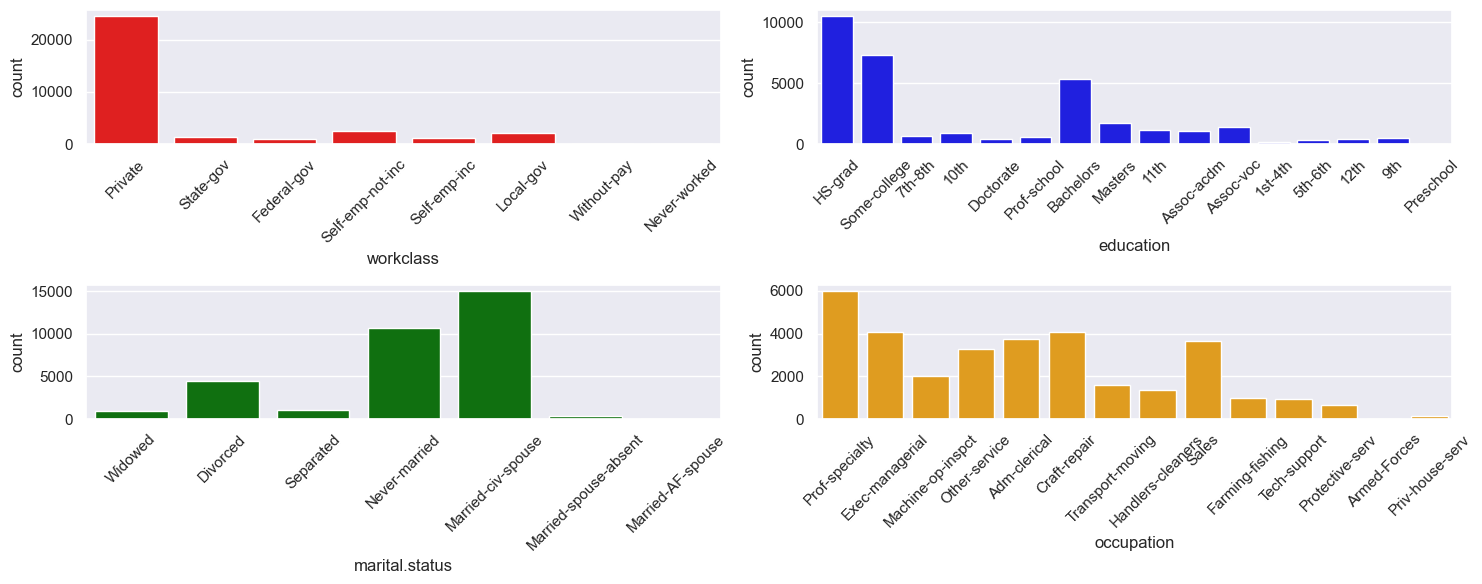

In [65]:
plt.style.use('fivethirtyeight')
sns.set(rc={"figure.figsize": (15, 6)})

columns = ['workclass', 'education', 'marital.status', 'occupation']
colors = ['red', 'blue', 'green', 'orange']

plt.figure()

for i, col in enumerate(columns):
    plt.subplot(2, 2, i+1)
    sns.countplot(x=col, data=df, color=colors[i])
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

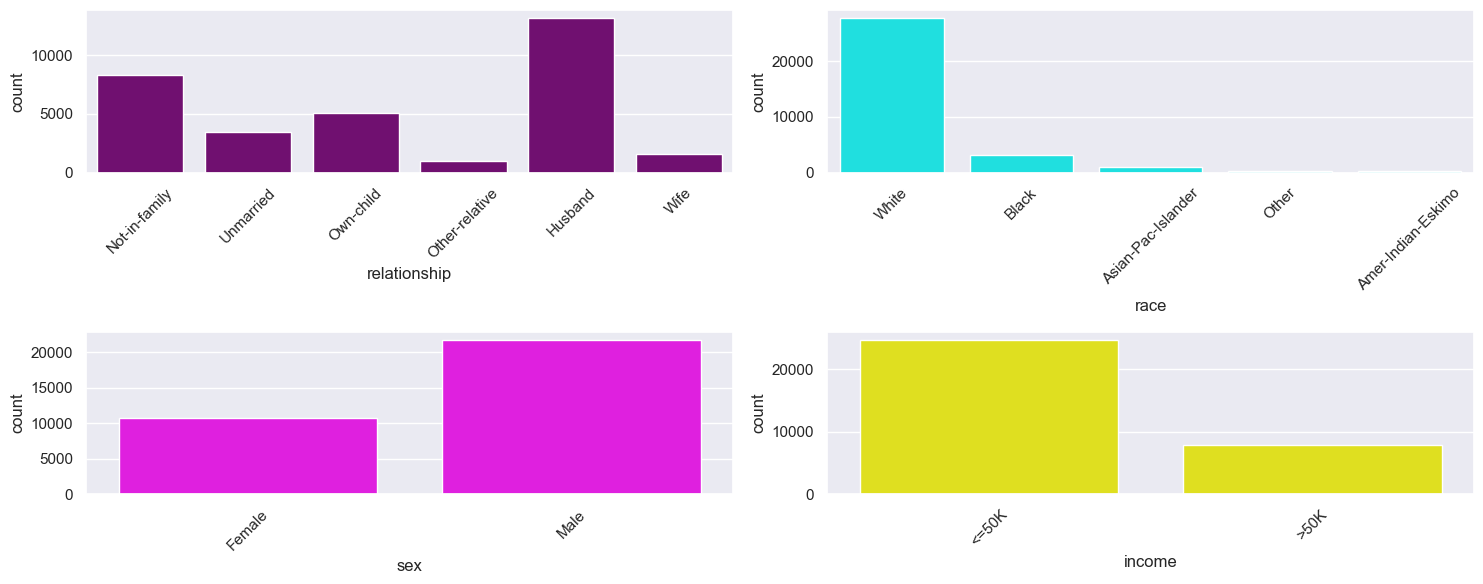

In [66]:
columns = ['relationship','race','sex','income']
colors = ['purple', 'cyan', 'magenta', 'yellow']

plt.figure()

for i, col in enumerate(columns):
    plt.subplot(2, 2, i+1)
    sns.countplot(x=col, data=df, color=colors[i])
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

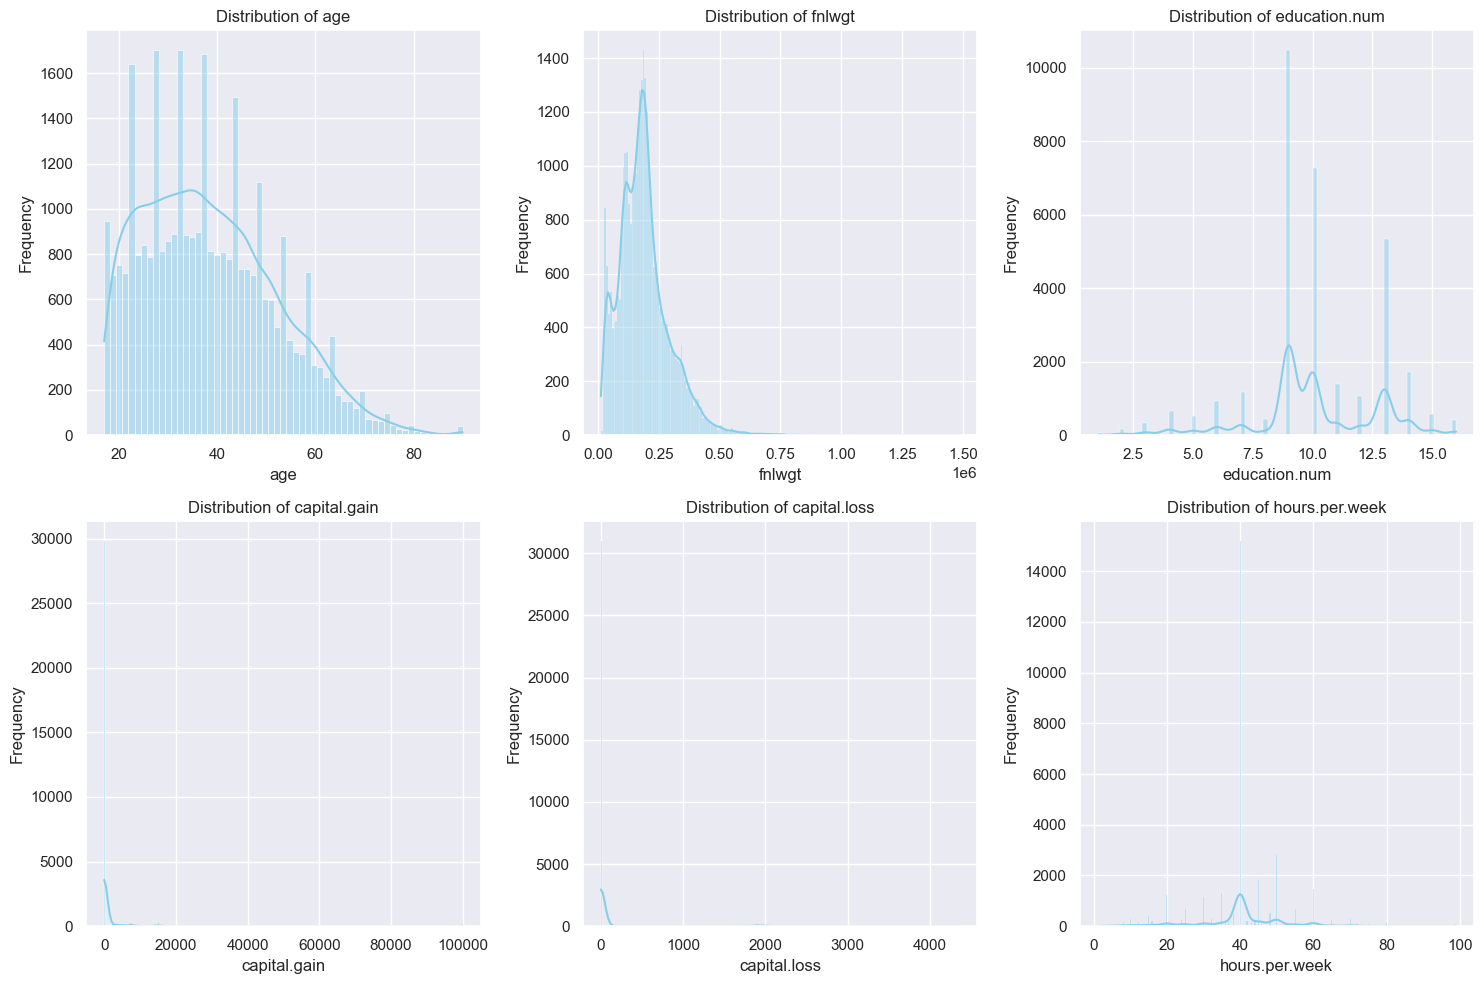

In [67]:
plt.figure(figsize=(15, 10))

for i, col in enumerate(numerical_features):
    plt.subplot(2, 3, i+1)
    sns.histplot(df[col], kde=True, color='skyblue')
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

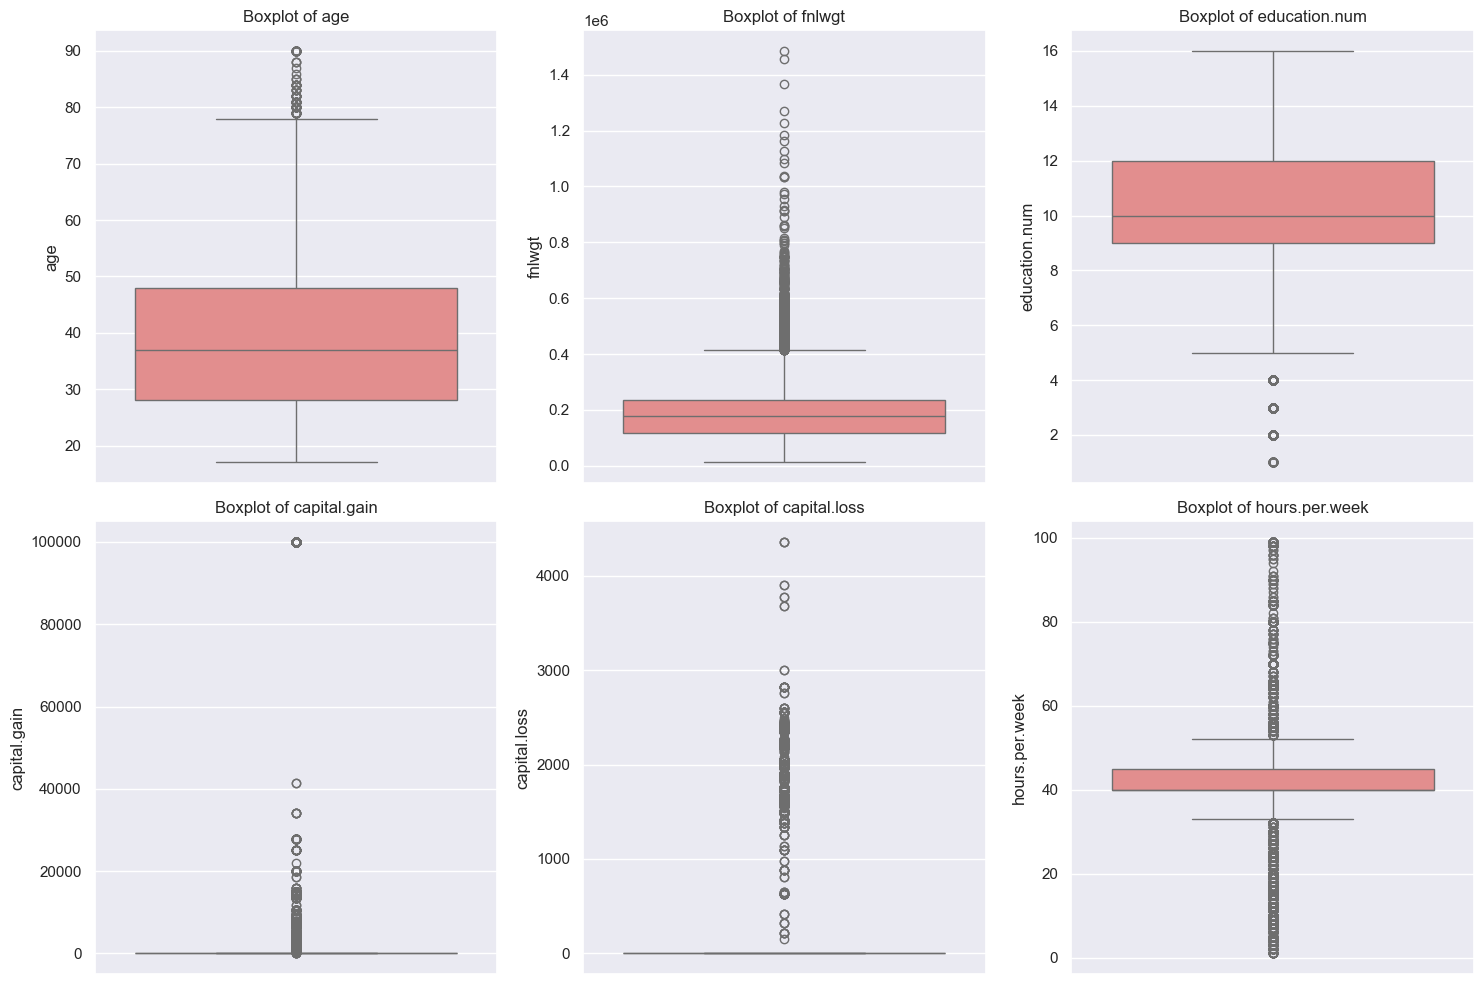

In [68]:
plt.figure(figsize=(15, 10))

for i, col in enumerate(numerical_features):
    plt.subplot(2, 3, i+1)
    sns.boxplot(y=df[col], color='lightcoral')
    plt.title(f'Boxplot of {col}')
    plt.ylabel(col)

plt.tight_layout()
plt.show()

<Axes: xlabel='income'>

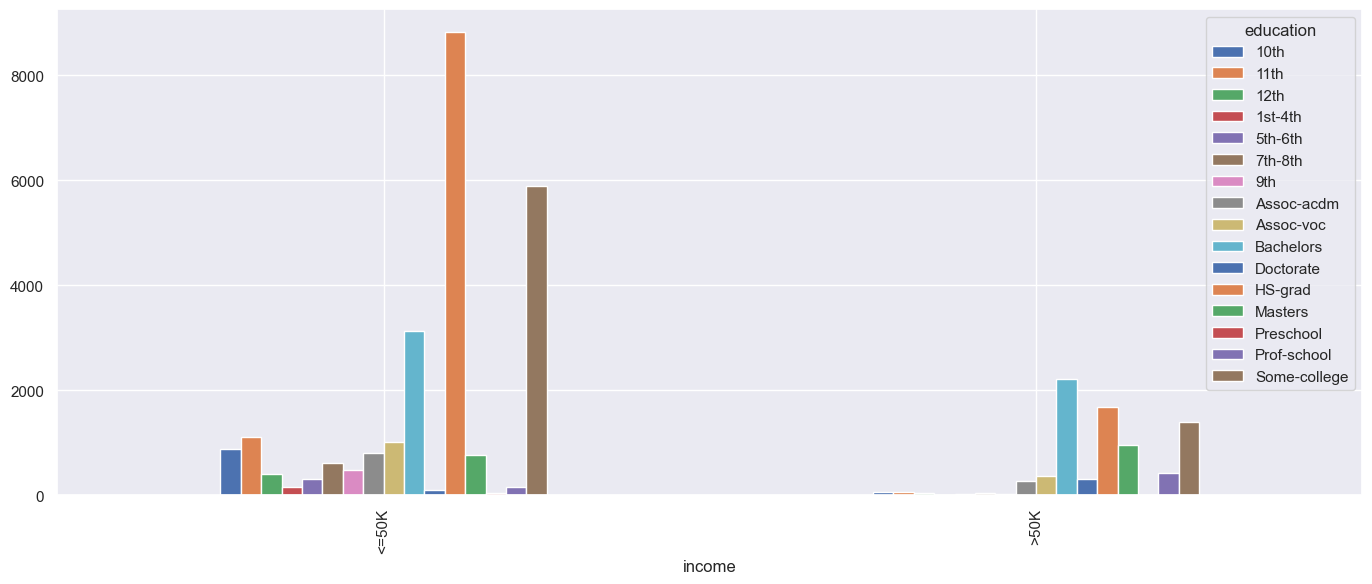

In [69]:
education=pd.crosstab(df['income'],df['education'])
education.plot(kind="bar")

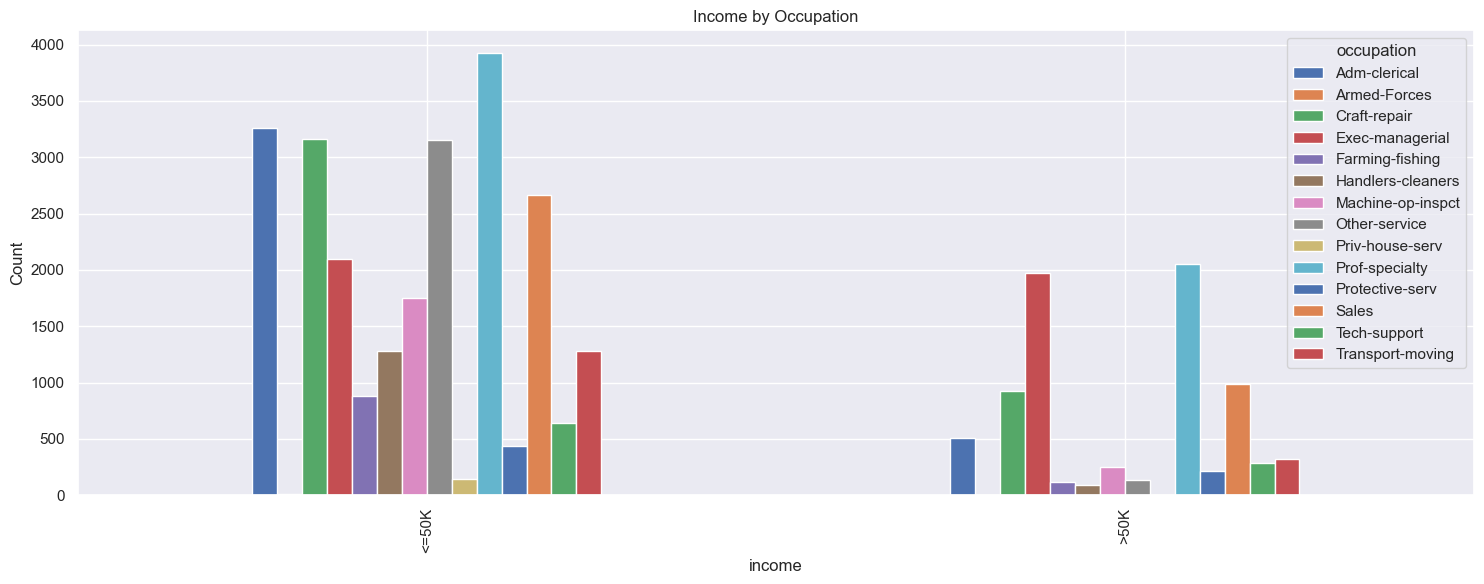

In [70]:
# crosstab and bar plot for occupation vs income
occupation_ct = pd.crosstab(df['income'], df['occupation'])
occupation_ct.plot(kind='bar', figsize=(15, 6))
plt.title('Income by Occupation')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

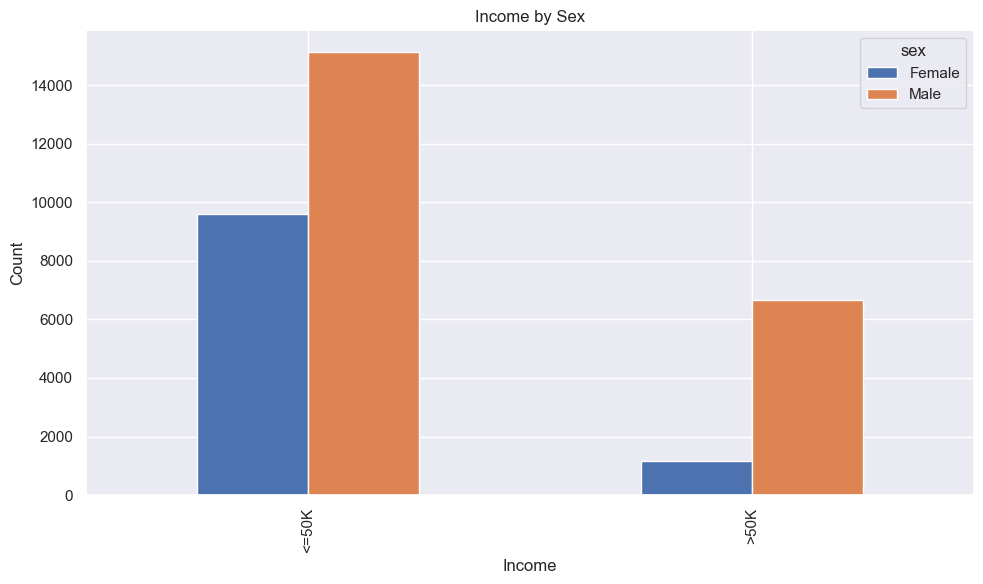

In [71]:
# crosstab and bar plot for sex vs income
sex_ct = pd.crosstab(df['income'], df['sex'])
sex_ct.plot(kind='bar', figsize=(10, 6))
plt.title('Income by Sex')
plt.ylabel('Count')
plt.xlabel('Income')
plt.tight_layout()
plt.show()

In [72]:
categorical_features

Index(['workclass', 'education', 'marital.status', 'occupation',
       'relationship', 'race', 'sex', 'native.country', 'income'],
      dtype='str')

In [73]:
from sklearn.preprocessing import LabelEncoder

le=LabelEncoder()

for feature in categorical_features:
    le.fit(df[feature])
    df[feature]=le.transform(df[feature ])

In [74]:
df['income'].value_counts()

income
0    24698
1     7839
Name: count, dtype: int64

In [76]:
df["income"].dtype

dtype('int64')

In [75]:
df["income"] = df["income"].str.strip()

df["income"] = df["income"].replace({
    "<=50K":0,
    ">50K":1,
    "<=50K.":0,
    ">50K.":1
})

AttributeError: Can only use .str accessor with string values, not integer

In [ ]:
#droping education_num colm because we have we have ordinal encode one

df.drop(['education','native.country','fnlwgt'],axis=1,inplace=True)

In [ ]:
df.head(5)

,age,workclass,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,income
0,90,3,9,6,9,1,4,0,0,4356,40,NaN
1,82,3,9,6,3,1,4,0,0,4356,18,NaN
2,66,3,10,6,9,4,2,0,0,4356,40,NaN
3,54,3,4,0,6,4,4,0,0,3900,40,NaN
4,41,3,10,5,9,3,4,0,0,3900,40,NaN


In [ ]:
df.to_csv("cleandata.csv",index=False)

In [ ]:
df.shape

(32537, 12)

In [77]:
df = df.dropna(subset=["income"])
x = df.drop("income", axis=1)
y = df["income"]

In [78]:
categorical_features=x.select_dtypes(include="object").columns
numerical_features=x.select_dtypes(exclude="object").columns

print(categorical_features)
print(numerical_features)

Index([], dtype='str')
Index(['age', 'workclass', 'fnlwgt', 'education', 'education.num',
       'marital.status', 'occupation', 'relationship', 'race', 'sex',
       'capital.gain', 'capital.loss', 'hours.per.week', 'native.country'],
      dtype='str')


In [79]:
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer



In [80]:
from sklearn.preprocessing import OneHotEncoder
num_pipline=Pipeline(
    steps=[
        ("imputer",SimpleImputer(strategy="median")),
        ("scalar",StandardScaler())
    ]
)

cato_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore"))
    ]
)

#apply transform to particular columns
preprocessor= ColumnTransformer([
    ("num_pipeline",num_pipline,numerical_features)
])

In [81]:
print(df.shape)
print(x.shape)
print(y.shape)

(32537, 15)
(32537, 14)
(32537,)


In [82]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [83]:
print("x_train shape:", x_train.shape)
print("x_test shape:", x_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

x_train shape: (26029, 14)
x_test shape: (6508, 14)
y_train shape: (26029,)
y_test shape: (6508,)


In [84]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)



In [85]:

def performance_metrics(test, predict):
    
    cm = confusion_matrix(test, predict)
    acc = accuracy_score(test, predict)
    prec = precision_score(test, predict)
    rec = recall_score(test, predict)
    f1 = f1_score(test, predict)
    
    print("CONFUSION MATRIX:\n", cm)
    print("\nAccuracy:", acc)
    print("Precision:", prec)
    print("Recall:", rec)
    print("F1-Score:", f1)
    
    return cm, acc, prec, rec, f1

## Use Hyperparemetertunning


In [86]:
lr=LogisticRegression()

In [ ]:
from sklearn.model_selection import GridSearchCV

param_lr = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'penalty': ['l2'],
    'solver': ['lbfgs', 'liblinear'],
    'max_iter': [100, 200, 500],
    'random_state': [42]
}



In [88]:
y_train.isnull().sum()

np.int64(0)

In [90]:
grid = GridSearchCV(estimator=lr, param_grid=param_lr, cv=5, scoring='accuracy', n_jobs=1)


grid.fit(x_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LogisticRegression()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [0.001, 0.01, ...], 'max_iter': [100, 200, ...], 'penalty': ['l2'], 'random_state': [42], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2

In [91]:

grid.best_params_

{'C': 1,
 'max_iter': 500,
 'penalty': 'l2',
 'random_state': 42,
 'solver': 'lbfgs'}

In [92]:
grid.score(x_train,y_train)

0.8097506627223482

In [93]:
y_pred=grid.predict(x_test)

In [94]:
accuracy_score(y_test,y_pred)

0.8125384142593731

In [95]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.84      0.94      0.88      4988
           1       0.66      0.41      0.50      1520

    accuracy                           0.81      6508
   macro avg       0.75      0.67      0.69      6508
weighted avg       0.80      0.81      0.80      6508

